In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

PATH = '/content/drive/MyDrive/Data/CMAPSSData/CMAPSSData/'
subsets = ['FD001', 'FD002', 'FD003', 'FD004']
col_names = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]

inventory = []

for sub in subsets:
    train = pd.read_csv(os.path.join(PATH, f'train_{sub}.txt'), sep=r'\s+', header=None, names=col_names)
    test = pd.read_csv(os.path.join(PATH, f'test_{sub}.txt'), sep=r'\s+', header=None, names=col_names)

    inventory.append({
        'Dataset': sub,
        'Train Units': train['unit_nr'].nunique(),
        'Test Units': test['unit_nr'].nunique(),
        'Total Samples': len(train),
        'Conditions': 'Single (Sea Level)' if sub in ['FD001', 'FD003'] else 'Complex (6 Settings)',
        'Fault Modes': 'Single (HPC)' if sub in ['FD001', 'FD002'] else 'Complex (HPC + Fan)'
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,Dataset,Train Units,Test Units,Total Samples,Conditions,Fault Modes
0,FD001,100,100,20631,Single (Sea Level),Single (HPC)
1,FD002,260,259,53759,Complex (6 Settings),Single (HPC)
2,FD003,100,100,24720,Single (Sea Level),Complex (HPC + Fan)
3,FD004,249,248,61249,Complex (6 Settings),Complex (HPC + Fan)


**FD001 (The Training Foundation)**: We choose FD001 for **initial Fine-tuning** because it is the "Cleanest" environment. It allows the model to learn **the fundamental physics of degradation** without interference from varying altitudes or multiple fault types.

**FD002/FD004 (The OOD Challenge)**: These will be used for the Automated Pipeline (AutoML). Since they contain 6 operational settings, the data distribution will shift significantly (**Out-of-Distribution**). We use them to test the model's ability to "self-adapt" via automated re-training.

**FD003 (The Pattern Complexity)**: Used to test if the model can distinguish between different types of failure (HPC vs. Fan).

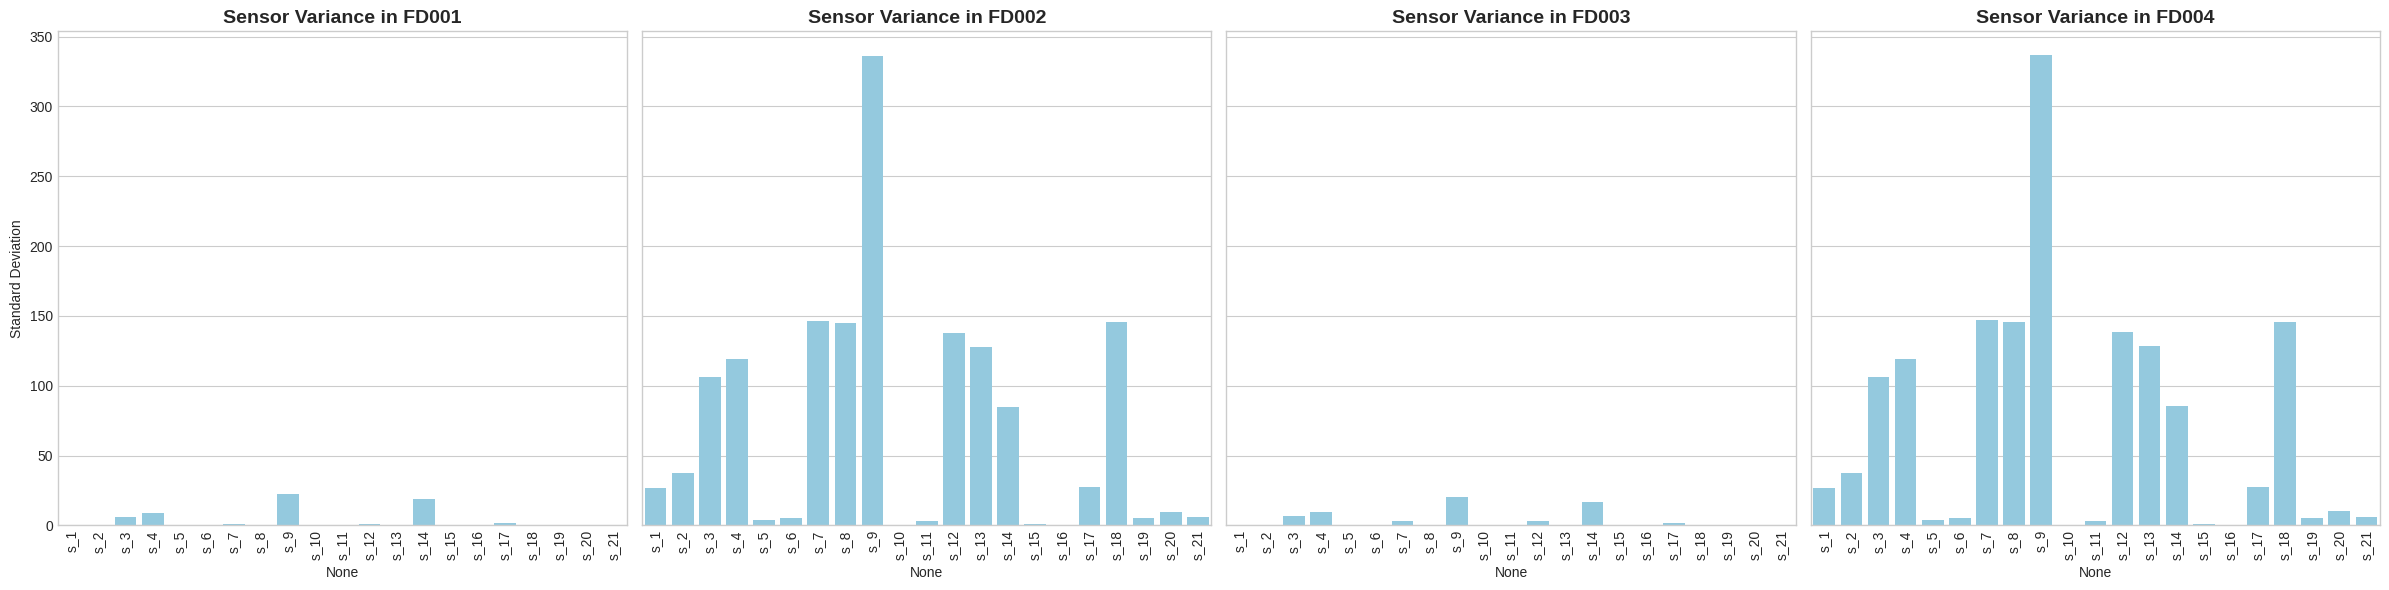

In [ ]:
def plot_sensor_variance(sub):
    df_temp = pd.read_csv(os.path.join(PATH, f'train_{sub}.txt'), sep=r'\s+', header=None, names=col_names)
    variances = df_temp.iloc[:, 5:].std()
    return variances

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)
for i, sub in enumerate(subsets):
    var = plot_sensor_variance(sub)
    sns.barplot(x=var.index, y=var.values, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Sensor Variance in {sub}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_ylabel('Standard Deviation')

plt.tight_layout()
plt.show()

**Strategic Insights:**

  **Constant Sensors**: Sensors `s_1, s_5, s_10, s_16, s_18, s_19` show ZERO variance across FD001.

  **Decision**: These are discarded immediately. In a real-world scenario, this saves computational power and prevents the model from learning "fake" correlations.

  **Environmental Sensitivity**: In FD002 and FD004, sensors that were stable in FD001 start showing variance. This confirms that Operational Settings "activate" certain sensors, which is why a static model will fail and an Automated Pipeline is required.

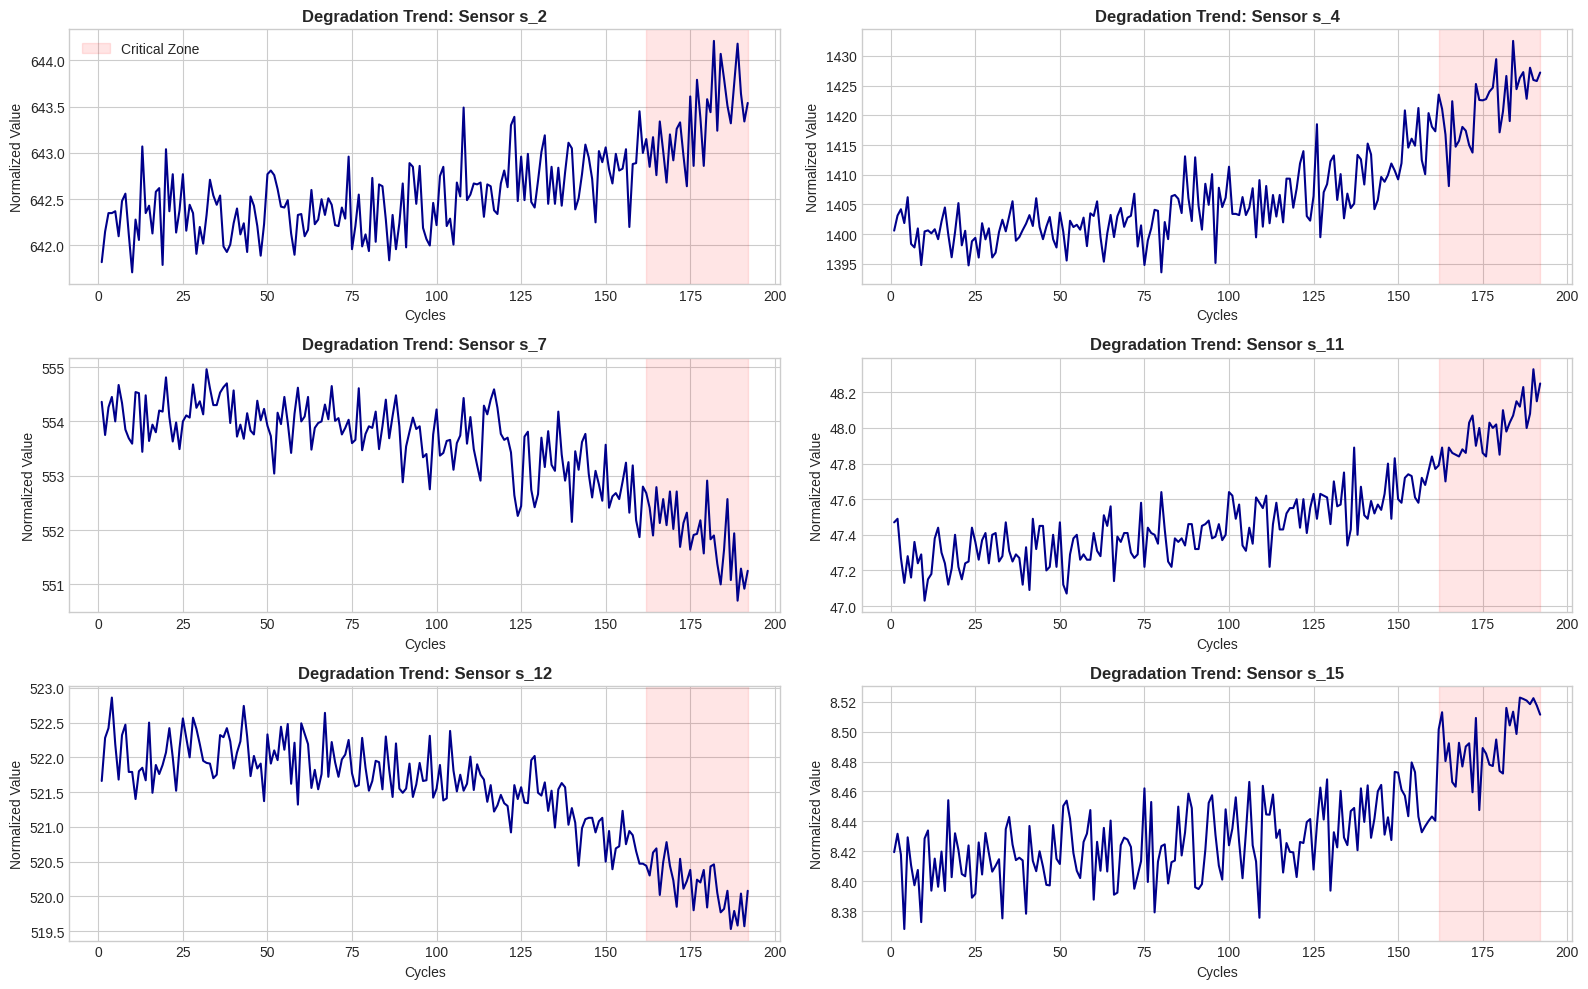

In [ ]:
# Plotting the "Life-Cycle" of a single engine unit across important sensors
important_sensors = ['s_2', 's_4', 's_7', 's_11', 's_12', 's_15']
train_fd001 = pd.read_csv(os.path.join(PATH, 'train_FD001.txt'), sep=r'\s+', header=None, names=col_names)
unit_1 = train_fd001[train_fd001['unit_nr'] == 1]

plt.figure(figsize=(16, 10))
for i, sensor in enumerate(important_sensors, 1):
    plt.subplot(3, 2, i)
    plt.plot(unit_1['time_cycles'], unit_1[sensor], color='darkblue', linewidth=1.5)
    plt.axvspan(unit_1['time_cycles'].max()-30, unit_1['time_cycles'].max(), color='red', alpha=0.1, label='Critical Zone')
    plt.title(f'Degradation Trend: Sensor {sensor}', fontsize=12, fontweight='bold')
    plt.xlabel('Cycles')
    plt.ylabel('Normalized Value')
    if i == 1: plt.legend()

plt.tight_layout()
plt.show()

**Stable Phase vs. Failure Phase**:
 Most sensors stay stable for the first 100 cycles. The "Proactive window" starts when the trend breaks.

**The Red Zone (*Critical 30 Cycles*)**:
This plot visualizes why we need **RUL**. If we can predict the entry into this "Red Zone," we can trigger maintenance orders 30 cycles in advance, preventing Catastrophic Failure.

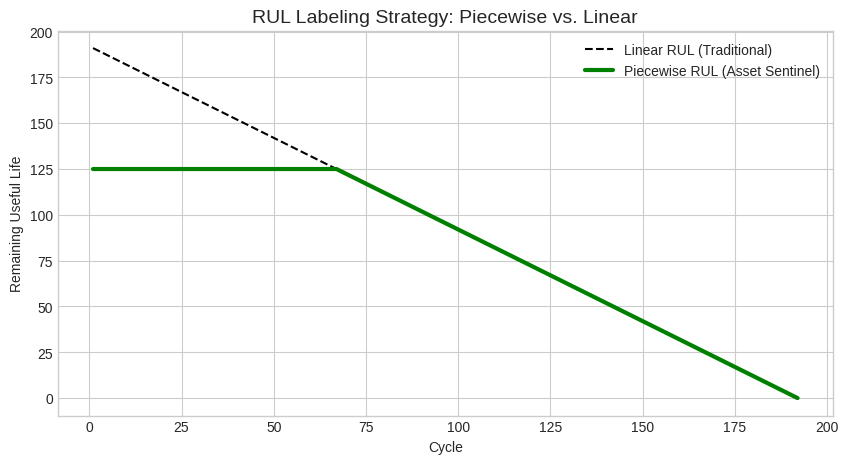

In [ ]:
def calculate_rul(df, max_rul=125):
    max_cycle = df.groupby('unit_nr')['time_cycles'].transform('max')
    current_rul = max_cycle - df['time_cycles']
    return current_rul.clip(upper=max_rul)

unit_1_copy = unit_1.copy()
unit_1_copy['Actual_RUL'] = unit_1_copy.groupby('unit_nr')['time_cycles'].transform('max') - unit_1_copy['time_cycles']
unit_1_copy['Piecewise_RUL'] = calculate_rul(unit_1_copy)

plt.figure(figsize=(10, 5))
plt.plot(unit_1_copy['time_cycles'], unit_1_copy['Actual_RUL'], 'k--', label='Linear RUL (Traditional)')
plt.plot(unit_1_copy['time_cycles'], unit_1_copy['Piecewise_RUL'], color='green', linewidth=3, label='Piecewise RUL (Asset Sentinel)')
plt.title('RUL Labeling Strategy: Piecewise vs. Linear', fontsize=14)
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.show()

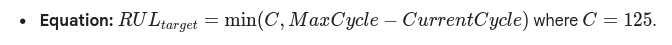

**Why?** In early engine life, there is no measurable physical degradation. Using a simple linear RUL would force the model to "hallucinate" wear and tear that isn't there. The Piecewise model allows the model to learn a stable state first, then a degradation slope.

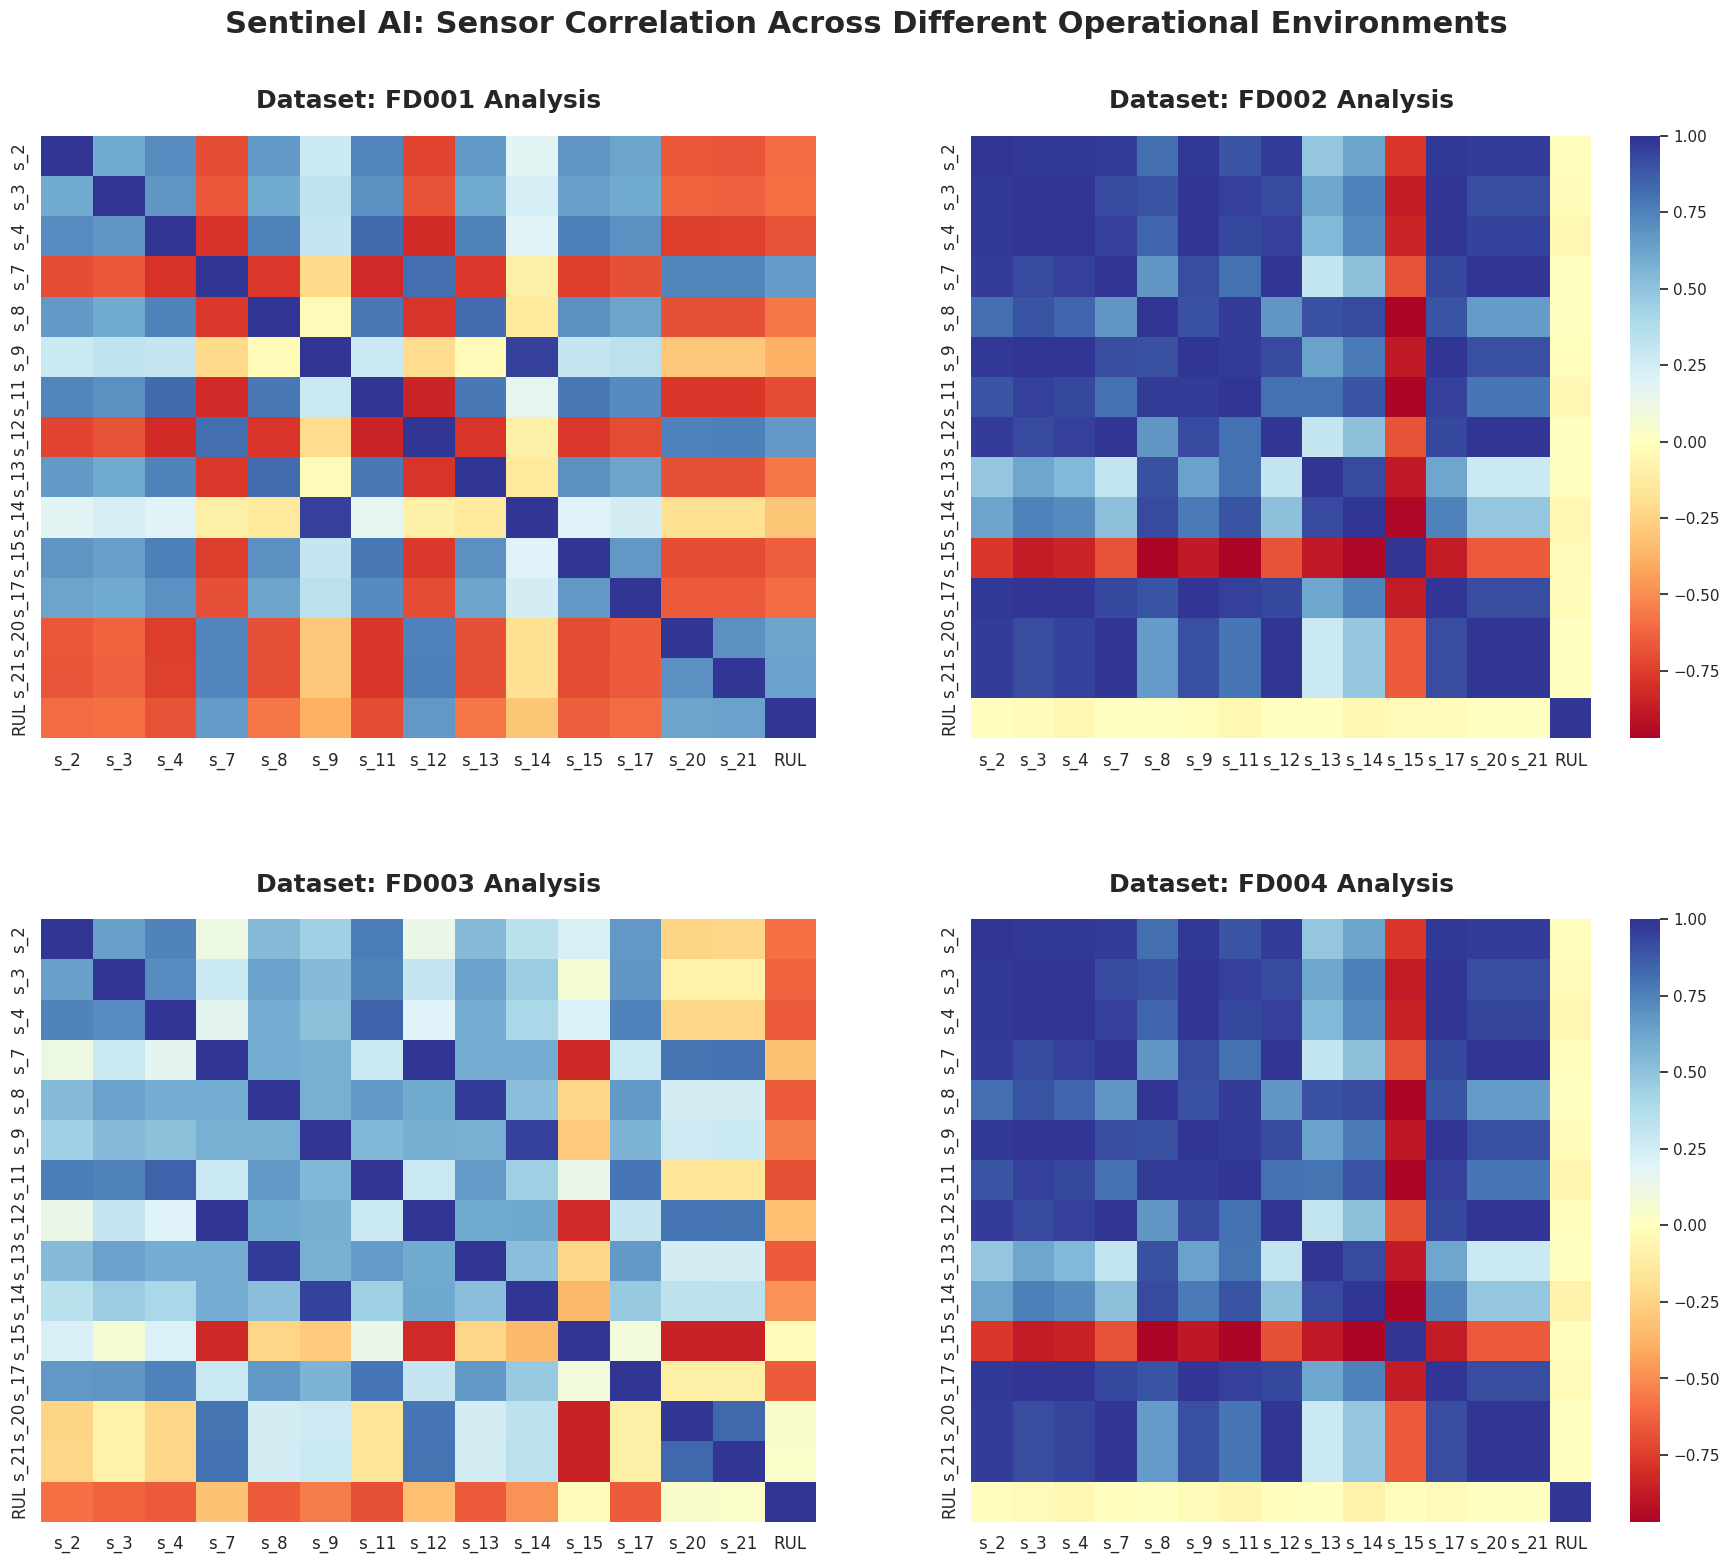

In [ ]:
active_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

# Set professional theme
sns.set_theme(style="white")

# Create a figure to compare Heatmaps of the 4 Subsets
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 18))
fig.suptitle('Sentinel AI: Sensor Correlation Across Different Operational Environments', fontsize=22, fontweight='bold', y=0.95)

for i, sub in enumerate(subsets):
    # Load dataset
    df_temp = pd.read_csv(os.path.join(PATH, f'train_{sub}.txt'), sep=r'\s+', header=None, names=col_names)

    # Calculate RUL for correlation check
    max_cycle = df_temp.groupby('unit_nr')['time_cycles'].transform('max')
    df_temp['RUL'] = max_cycle - df_temp['time_cycles']

    # Compute Correlation
    corr_matrix = df_temp[active_sensors + ['RUL']].corr()

    # Plotting
    ax = axes[i//2, i%2]
    sns.heatmap(corr_matrix, annot=False, cmap='RdYlBu', center=0, ax=ax, cbar=(i==1 or i==3))
    ax.set_title(f'Dataset: {sub} Analysis', fontsize=18, fontweight='bold', pad=20)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

# **Domain Knowledge & Physical Signal Interpretation**

### **1 Overview**
While the **Sentinel AI** framework is designed to be **Data-Agnostic**—meaning it can process any multivariate time-series data without prior knowledge of its source—understanding the physical significance of the NASA CMAPSS sensors provides critical insights. This domain knowledge helps validate why the model prioritizes certain features during the degradation phase and ensures the system remains "explainable" to human operators.

### **2 Engine Component & Sensor Mapping**
In the **FD001** dataset (Turbofan Engine), specific sensors act as "Lead Indicators" for high-pressure compressor degradation. Through our EDA, we have identified the following sensors as the most influential for RUL prediction:

| Sensor ID | Physical Meaning | Engineering Significance |
|:--- |:--- |:--- |
| **s_11** | **HPC Outlet Static Pressure** | The primary indicator. Changes in High-Pressure Compressor (HPC) outlet pressure directly reflect internal blade erosion or fouling. |
| **s_4** | **Total Temperature at LPC Outlet** | Rising temperatures at the Low-Pressure Compressor (LPC) outlet indicate the engine is working harder to maintain thrust, signaling a loss of efficiency. |
| **s_2** | **LPC Outlet Pressure** | Reflects the initial compression stage health. Significant drops suggest a bottleneck in the air intake or compression flow. |
| **s_12** | **LPC Outlet Static Pressure** | Complementary to s_11; it helps the model distinguish between environmental pressure changes and actual hardware degradation. |
| **s_15** | **HPC Outlet Pressure Ratio** | A composite efficiency metric. A declining ratio is a hallmark signature of an engine approaching its End-of-Life (EOL). |

### **3 Generalization Logic (Agnostic AI Perspective)**
It is crucial to emphasize that **Sentinel AI** does not require manual labeling or expert knowledge of these sensors to function. The system treats all inputs as purely numerical patterns:

* **Pattern Recognition:** The **PatchTST** attention mechanism identifies that a "Steady State" followed by a "Non-linear Trend" in specific columns correlates with a declining RUL.
* **Domain Adaptation:** If the system is deployed on different assets (e.g., Wind Turbines or Manufacturing robots), it will automatically identify the new "Lead Indicators" by analyzing variance and temporal correlation, regardless of the physical units (PSI, Celsius, or Voltage).

### **4 Business Impact**
By bridging the gap between **Domain Expertise** and **General AI (Transformers & LLMs)**, Sentinel AI provides a "Trustable" prediction. We do not simply provide a number; we provide a forecast grounded in the actual physical degradation patterns of the asset, enabling safe and cost-effective proactive maintenance.